In [18]:
import DataMaker
import DataHolder
import buildmodel

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle

import cartopy.crs as ccrs

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [2]:
ssplist = ["126","245","370","585"]

# ssplist = ["245"]#,"370","585"]

# set user parameters

# historical_era = [1960,2000]
experiment_era = [1950,2100]
baselineera = [1900,1950]
# tpercentile = 95
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

inputlength = 10
outputavgtime = 10

# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]



In [3]:
imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
}

ntrain = 25
nval = 13
test = np.arange(38,50)


#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon

data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


In [4]:
def confacc(predclass,trueclass,predconf):

    predcorr = predclass==trueclass
    percentiles = np.arange(0,100,5)
    accper = np.empty(20)
    for iper,per in enumerate(percentiles):

        perboo = np.percentile(predconf,per)
        accper[iper] = np.mean(predcorr[predconf>perboo])

    return accper

In [5]:
trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)

trainvaltest = [trainval[:ntrain],trainval[ntrain:ntrain+nval],test]

alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,-20,0)

_, inputtrainGMT, _ = DataHolder.tensortime_onehot(alltrain,nclasses=2)
_, inputvalGMT, _ = DataHolder.tensortime_onehot(allval,nclasses=2)
_, inputtestGMT, _ = DataHolder.tensortime_onehot(alltest,nclasses=2)


baseline for gmt is 60 90
experiment era in the historical is 50 124
baseline for temp records is 0 50
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/DataHolder.py:1379: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


In [6]:
regenerate = False

logisticaccuracy = np.empty((len(AllData.output_lat),len(AllData.output_lon),20))+np.nan
emergencegmt = np.empty((len(AllData.output_lat),len(AllData.output_lon)))+np.nan
intercepts = np.empty((len(AllData.output_lat),len(AllData.output_lon)))+np.nan
coefficients = np.empty((len(AllData.output_lat),len(AllData.output_lon)))+np.nan

for ilatsel,latsel in enumerate(AllData.output_lat):
    print(latsel)

    if (latsel>=0) & (regenerate==False):

        alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,10,0)

        _, inputtrainGMT, _ = DataHolder.tensortime_onehot(alltrain,nclasses=2)
        _, inputvalGMT, _ = DataHolder.tensortime_onehot(allval,nclasses=2)
        _, inputtestGMT, _ = DataHolder.tensortime_onehot(alltest,nclasses=2)

        regenerate = True
        
    for ilonsel,lonsel in enumerate(AllData.output_lon):

        outputtrainall, outputvalall, outputtestall = AllData.trainvaltest_recordmax_outputonly(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)
        class_imbalance = np.mean(outputtrainall)

        if (class_imbalance!=0) & (class_imbalance!=1):

            model = LogisticRegression()

            # Fit the model
            model.fit(inputtrainGMT.numpy(), outputtrainall.squeeze())

            # Make predictions
            y_pred = model.predict(inputtestGMT.numpy())
            y_pred_proba = model.predict_proba(inputtestGMT.numpy())  # Get probabilities

            y_conf = np.max(y_pred_proba,axis=1)

            logisticaccuracy[ilatsel,ilonsel] = confacc(y_pred.squeeze(),outputtestall.squeeze(),y_conf)

            intercept = model.intercept_[0]
            coefficient = model.coef_[0][0]  # assuming single feature

            decision_boundary = -intercept / coefficient

            intercepts[ilatsel,ilonsel] = intercept
            coefficients[ilatsel,ilonsel] = coefficient

            if ((decision_boundary<=np.max(inputtestGMT.numpy()))) & (coefficient>0):

                emergencegmt[ilatsel,ilonsel] = decision_boundary            

        else:
            logisticaccuracy[ilatsel,ilonsel,:]= np.nan




-90
-80
-70
-60
-50
-40
-30
-20
-10
0
baseline for gmt is 60 90
experiment era in the historical is 50 124
baseline for temp records is 0 50
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/DataHolder.py:1379: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


10
20
30
40
50
60
70
80


In [7]:
y_pred


array([0, 0, 0, ..., 1, 1, 1])

In [8]:
def get_best_seeds(filelist,n_best=3):
    results = []
    for file in filelist:
        with open(file, 'r') as f:
            results.append(json.load(f))
    
    allaccs = np.asarray([results[i]['val_accuracy'] for i in range(filelist)])
    allnulls = np.asarray([results[i]['val_class_imbalance'] for i in range(filelist)])
    bestseedinds = np.argsort(allaccs-allnulls)[-n_best:]
    
    return bestseedinds

In [9]:
bestaccs = np.empty((len(latvec),len(lonvec),20))
nulls = np.empty((len(latvec),len(lonvec)))

for ilatsel,latsel in enumerate(latvec):
    for ilonsel,lonsel in enumerate(lonvec):
        testfileout = "metrics/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_lon"+str(lonsel)+"_testing.json"
        fileload = glob.glob(testfileout)

        if len(fileload)==0:
            bestaccs[ilatsel,ilonsel] = np.nan
            nulls[ilatsel,ilonsel] = np.nan
        else:

            with open(testfileout, "r") as f:
                data = json.load(f)
                bestaccs[ilatsel,ilonsel] = np.array(data["test_accuracy"])
                nulls[ilatsel,ilonsel] = np.max(np.array(data["test_class_imbalance"]))



            


In [10]:
bestaccs.shape

(18, 36, 20)

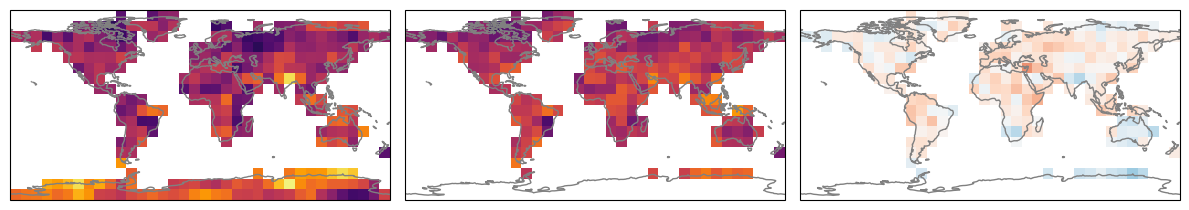

In [11]:
plt.figure(figsize=(12,5))

confsel = 10

a1=plt.subplot(1,3,1,projection=ccrs.PlateCarree())
a1.pcolormesh(lonvec+5,latvec+5,logisticaccuracy[:,:,confsel],vmin=0.5,vmax=0.9,cmap='inferno')
a1.coastlines(color='gray')

a1=plt.subplot(1,3,2,projection=ccrs.PlateCarree())
a1.pcolormesh(lonvec+5,latvec+5,bestaccs[:,:,confsel],vmin=0.5,vmax=0.9,cmap='inferno')
a1.coastlines(color='gray')

a1=plt.subplot(1,3,3,projection=ccrs.PlateCarree())
a1.pcolormesh(lonvec+5,latvec+5,bestaccs[:,:,confsel]-logisticaccuracy[:,:,confsel],vmin=-0.3,vmax=0.3,cmap='RdBu_r')
a1.coastlines(color='gray')

plt.tight_layout()

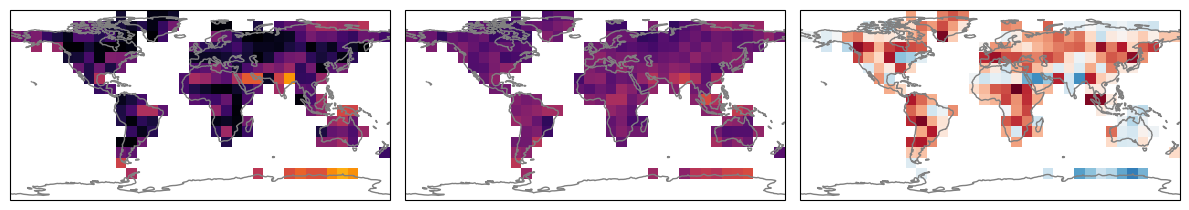

In [12]:
plt.figure(figsize=(12,5))

a1=plt.subplot(1,3,1,projection=ccrs.PlateCarree())
a1.pcolormesh(lonvec+5,latvec+5,nulls,vmin=0.5,vmax=0.9,cmap='inferno')
a1.coastlines(color='gray')

a1=plt.subplot(1,3,2,projection=ccrs.PlateCarree())
a1.pcolormesh(lonvec+5,latvec+5,bestaccs[:,:,0],vmin=0.5,vmax=0.9,cmap='inferno')
a1.coastlines(color='gray')

a1=plt.subplot(1,3,3,projection=ccrs.PlateCarree())
a1.pcolormesh(lonvec+5,latvec+5,bestaccs[:,:,0]-nulls,vmin=-0.15,vmax=0.15,cmap='RdBu_r')
a1.coastlines(color='gray')

plt.tight_layout()

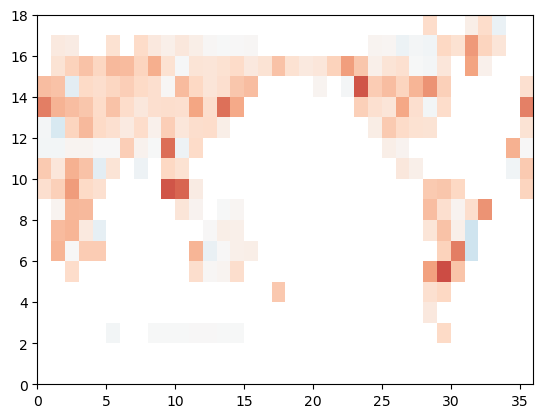

In [13]:
plt.pcolormesh(logisticaccuracy[:,:,0]-nulls,vmin=-0.2,vmax=0.2,cmap="RdBu_r")

In [ ]:
inputtestGMT = np.asarray(inputtestGMT)

gmt_first_positive = np.empty((len(AllData.output_lat),len(AllData.output_lon)))
gmt_first_confident = np.empty((len(AllData.output_lat),len(AllData.output_lon)))
gmt_first_correct = np.empty((len(AllData.output_lat),len(AllData.output_lon)))

for ilatsel,latsel in enumerate(AllData.output_lat):

    fileopen = "predictions/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_testing.pkl"

    filecheck = glob.glob(fileopen)
    if len(filecheck) != 0:

        with open(filecheck[0],'rb') as f:
            predictions = pickle.load(f)

        avgtestpred = np.mean(predictions,axis=1)
        avgtestclass = np.round(avgtestpred)
        avgtestconf = np.where(avgtestpred<0.5,1-avgtestpred,avgtestpred)

        for ilonsel,lonsel in enumerate(AllData.output_lon):
            if np.mean(avgtestpred) != 0:
                # first positive prediction
                gmt_first_positive = np.min(inputtestGMT[avgtestclass[ilonsel]==1])

                # first confident, positive prediction
                percentile = np.percentile(avgtestconf[ilonsel],q=50)
                gmt_first_confident = np.min(inputtestGMT[(avgtestclass[ilonsel]==1) & (avgtestconf>percentile)])

                # first correct, positive prediction 
                gmt_first_correct = np.min(inputtestGMT[(avgtestclass[ilonsel]==1) & (avgtestconf>percentile)])
        


In [21]:
predictions.shape

(36, 3, 3972)

In [22]:
inputtestGMT.shape

torch.Size([3972, 1])